Data Preprocessing, Regression and Support vector machines

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Q1 : Data Preprocessing

```
# This is formatted as code
```



In [ ]:
# Load the dataset
cars_df = pd.read_csv('Cars93.csv')
print("Dataset Shape:", cars_df.shape)
print("\nFirst few rows:\n", cars_df.head())
print("\ndata types:\n", df.dtypes)
print("\nMissing values in each column:\n", df.isnull().sum())

print("\nBasic statistics of numerical columns:\n", df.describe())

# 1. Assign a type to each of the following feature

# According to the assignment:
#   a. Model      : Nominal
#   b. Type       : Nominal
#   c. Max. Price : Ratio
#   d. Airbags    : Ratio

print("Feature Scale Assignments:")
print("Model     : Nominal")
print("Type      : Nominal")
print("Max. Price: Ratio")
print("Airbags   : Ratio\n")

Dataset Shape: (93, 26)

First few rows:
   Manufacturer    Model     Type  Min.Price  Price  Max.Price  MPG.city  \
0        Acura  Integra    Small       12.9   15.9       18.8        25   
1        Acura   Legend  Midsize       29.2   33.9       38.7        18   
2         Audi       90  Compact       25.9   29.1       32.3        20   
3         Audi      100  Midsize       30.8   37.7       44.6        19   
4          BMW     535i  Midsize       23.7   30.0       36.2        22   

   MPG.highway             AirBags DriveTrain  ... Fuel.tank.capacity  \
0           31                 NaN      Front  ...               13.2   
1           25  Driver & Passenger      Front  ...               18.0   
2           26         Driver only      Front  ...               16.9   
3           26  Driver & Passenger      Front  ...               21.1   
4           30         Driver only       Rear  ...               21.1   

   Passengers  Length  Wheelbase  Width Turn.circle  Rear.seat.room 

In [ ]:
# 2. Handling Missing Values in the dataset

def handle_missing_values(df):
    # Identify columns with missing values (e.g., Luggage.room)
    missing_cols = df.columns[df.isna().any()].tolist()

    # Numerical columns: Impute with median
    num_cols = df.select_dtypes(include=np.number).columns
    for col in num_cols:
        if col in missing_cols:
            df[col] = df[col].fillna(df[col].median())

    # Categorical columns: Impute with mode
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        if col in missing_cols:
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

cars_df = handle_missing_values(cars_df)
print("Missing Values After Imputation:\n", cars_df.isnull().sum())
print("\nUpdated data frame with missing values handled:\n", cars_df.describe())

Missing Values After Imputation:
 Manufacturer          0
Model                 0
Type                  0
Min.Price             0
Price                 0
Max.Price             0
MPG.city              0
MPG.highway           0
AirBags               0
DriveTrain            0
Cylinders             0
EngineSize            0
Horsepower            0
RPM                   0
Rev.per.mile          0
Man.trans.avail       0
Fuel.tank.capacity    0
Passengers            0
Length                0
Wheelbase             0
Width                 0
Turn.circle           0
Rear.seat.room        0
Luggage.room          0
Weight                0
Origin                0
dtype: int64

Updated data frame with missing values handled:
        Min.Price      Price  Max.Price   MPG.city  MPG.highway  EngineSize  \
count  93.000000  93.000000  93.000000  93.000000    93.000000   93.000000   
mean   17.125806  19.509677  21.898925  22.365591    29.086022    2.667742   
std     8.746029   9.659430  11.030457   5.61

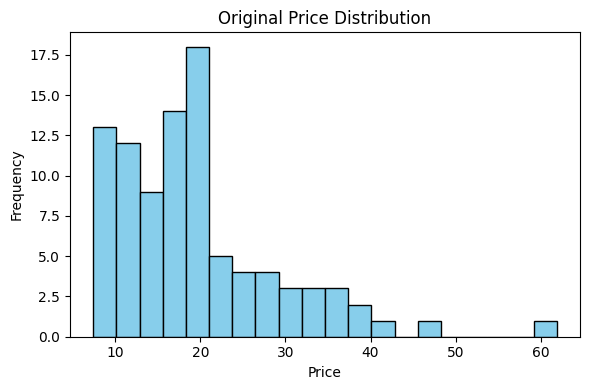

In [ ]:
# Visualization: Price Distribution Before Noise Reduction ---
plt.figure(figsize=(6,4))
plt.hist(pd.read_csv('Cars93.csv')['Price'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title("Original Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# 2. Reducing Noise
def reduce_noise(df):
    """
    Removes rows and caps with extreme numerical values using IQR.
    Non-positive price values are also removed.
    """
    # Remove rows with non-positive entries in key price columns.
    df = df[(df['Min.Price'] > 0) & (df['Price'] > 0) & (df['Max.Price'] > 0)]

    num_cols = df.select_dtypes(include=np.number).columns
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower_bound, upper_bound)
    return df

cars_df = reduce_noise(cars_df)
print("Noise reduction complete")

Noise reduction complete


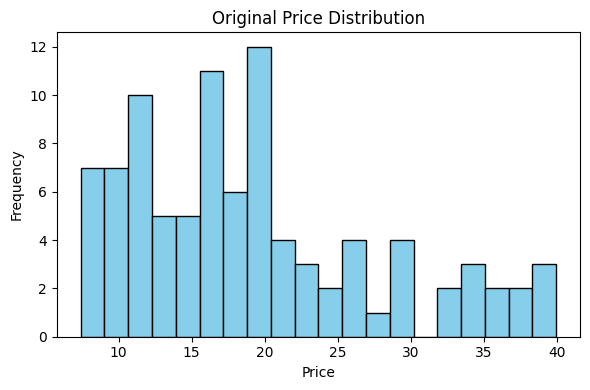

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(cars_df['Price'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title("Original Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# Task 4: Encode Categorical Features

def encode_categorical_features(df):
    """
    Handles encoding of categorical features.
    - For AirBags (ordinal), first convert values explicitly to strings and strip unwanted spaces,
      then apply ordinal encoding using the order: "None" < "Driver only" < "Driver & Passenger".
    - For remaining categorical features, apply one-hot encoding.
    """
    # Encode the 'AirBags' column as ordinal.
    if "AirBags" in df.columns:
        # Convert to string and strip spaces
        df["AirBags"] = df["AirBags"].astype(str).str.strip()

        # Check if there are numeric values in AirBags column
        numeric_values = df["AirBags"].str.match(r'^\d+\.?\d*$')
        if numeric_values.any():
            # Map numeric values to their corresponding categories if needed
            # This assumes 0.0 = None, 1.0 = Driver only, 2.0 = Driver & Passenger
            mapping = {'0.0': 'None', '0': 'None',
                      '1.0': 'Driver only', '1': 'Driver only',
                      '2.0': 'Driver & Passenger', '2': 'Driver & Passenger'}
            df["AirBags"] = df["AirBags"].map(lambda x: mapping.get(x, x))

        airbags_order = ['None', 'Driver only', 'Driver & Passenger']
        ordinal_encoder = OrdinalEncoder(categories=[airbags_order], handle_unknown='use_encoded_value', unknown_value=-1)
        df["AirBags"] = ordinal_encoder.fit_transform(df[["AirBags"]])

    # Identify remaining categorical columns.
    cat_cols = [col for col in df.select_dtypes(include="object").columns if col != "AirBags"]

    # One-hot encode remaining categorical features.
    if cat_cols:
        # Use 'sparse_output=False' for scikit-learn versions 1.2 and later.
        onehot_encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore')
        onehot_encoded = onehot_encoder.fit_transform(df[cat_cols])
        onehot_encoded_df = pd.DataFrame(onehot_encoded,
                                         columns=onehot_encoder.get_feature_names_out(cat_cols))
        df = df.drop(columns=cat_cols).reset_index(drop=True)
        df = pd.concat([df, onehot_encoded_df.reset_index(drop=True)], axis=1)

    return df


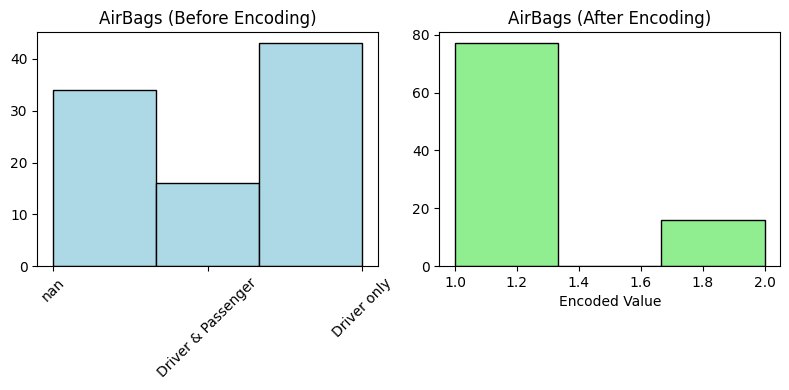

Categorical features encoded.


In [ ]:
# Visualize distribution for "AirBags" before encoding (based on original data)
if "AirBags" in cars_df.columns:
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    original_airbags = pd.read_csv('Cars93.csv')["AirBags"].astype(str).str.strip()
    plt.hist(original_airbags, bins=3, color='lightblue', edgecolor='black')
    plt.title("AirBags (Before Encoding)")
    plt.xticks(rotation=45)

    # Create a temporary dataframe copy for encoding visualization.
    df_encoded_temp = encode_categorical_features(cars_df.copy())
    plt.subplot(1, 2, 2)
    plt.hist(df_encoded_temp["AirBags"], bins=3, color='lightgreen', edgecolor='black')
    plt.title("AirBags (After Encoding)")
    plt.xlabel("Encoded Value")

    plt.tight_layout()
    plt.show()

# Update our main dataframe with encoded categorical features.
cars_df = encode_categorical_features(cars_df)
print("Categorical features encoded.")

In [ ]:
# ------------------------
# 4. Normalizing / Scaling Features
# ------------------------
def normalize_features(dataframe, columns=None):
    df_normalized = dataframe.copy()
    scaler = MinMaxScaler()
    if columns is None:
        columns = df_normalized.columns.tolist()
    df_normalized[columns] = scaler.fit_transform(df_normalized[columns])
    return df_normalized

In [ ]:
# Normalize the numerical features in the encoded dataset.
num_cols = cars_df.select_dtypes(include=[np.number]).columns.tolist()
df_normalized = normalize_features(cars_df, num_cols)

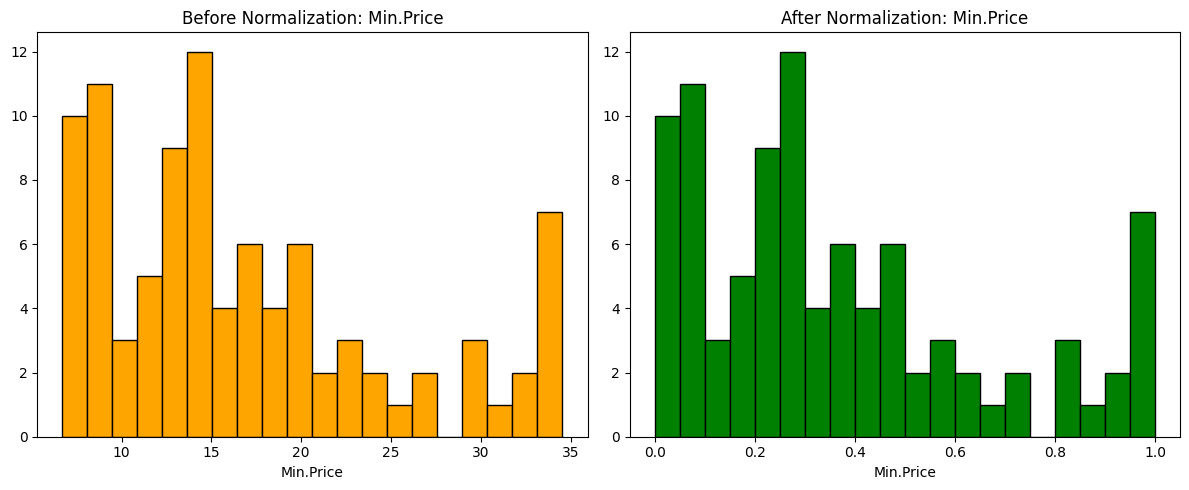

In [ ]:
# Plot 2: Comparison of a Numeric Feature Before and After Normalization
if num_cols:
    # Select a representative numeric feature (using the first numeric column)
    feature = num_cols[0]
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    df_encoded_temp = encode_categorical_features(cars_df)
    plt.hist(df_encoded_temp[feature], bins=20, color='orange', edgecolor='black')
    plt.title(f"Before Normalization: {feature}")
    plt.xlabel(feature)

    plt.subplot(1, 2, 2)
    plt.hist(df_normalized[feature], bins=20, color='green', edgecolor='black')
    plt.title(f"After Normalization: {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

In [ ]:
# ------------------------
# 5. Creating a Random Train-Validation-Test Split (70:20:10)
# ------------------------
def split_dataset(dataframe, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, random_state=42):
    # Ensure that the ratios sum up to 1
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"
    train, temp = train_test_split(dataframe, test_size=(1 - train_ratio), random_state=random_state)
    relative_test_ratio = test_ratio / (val_ratio + test_ratio)
    val, test = train_test_split(temp, test_size=relative_test_ratio, random_state=random_state)
    return train, val, test

train_df, val_df, test_df = split_dataset(df_normalized)

In [ ]:
# ------------------------
# Final Split Summary
# ------------------------
print("Data split shapes:")
print("Train set shape:      ", train_df.shape)
print("Validation set shape: ", val_df.shape)
print("Test set shape:       ", test_df.shape)

Data split shapes:
Train set shape:       (65, 156)
Validation set shape:  (18, 156)
Test set shape:        (10, 156)


# Q2: Linear Regression


Cleaned column names: ['Height', 'Weight']


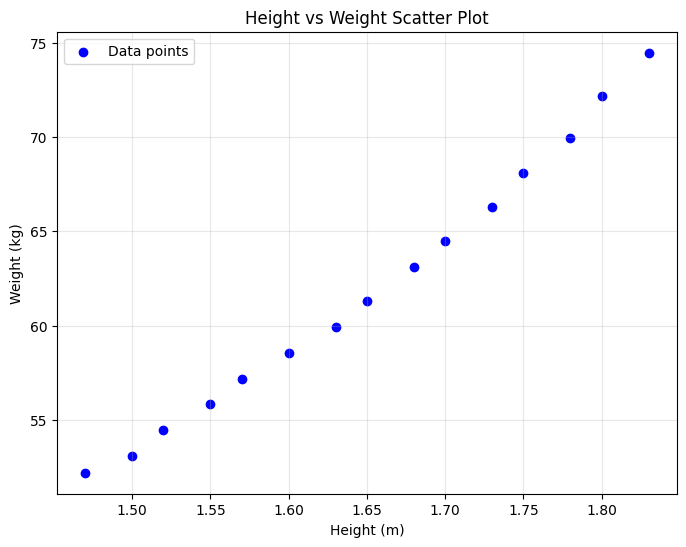

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the dataset
data = pd.read_csv('linear_regression_dataset.csv')

# Use the exact column name with trailing space
data.columns = data.columns.str.strip()
print("Cleaned column names:", data.columns.tolist())

# Now we can use 'Height' without trailing space
plt.figure(figsize=(8, 6))
plt.scatter(data['Height'], data['Weight'], color='blue', label='Data points')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.title('Height vs Weight Scatter Plot')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Prepare data for sklearn implementation
X = data['Height'].values.reshape(-1, 1)  # Independent variable as 2D array
y = data['Weight'].values  # Dependent variable

Sklearn Model - Coefficient (slope): 61.2722
Sklearn Model - Intercept: -39.0620


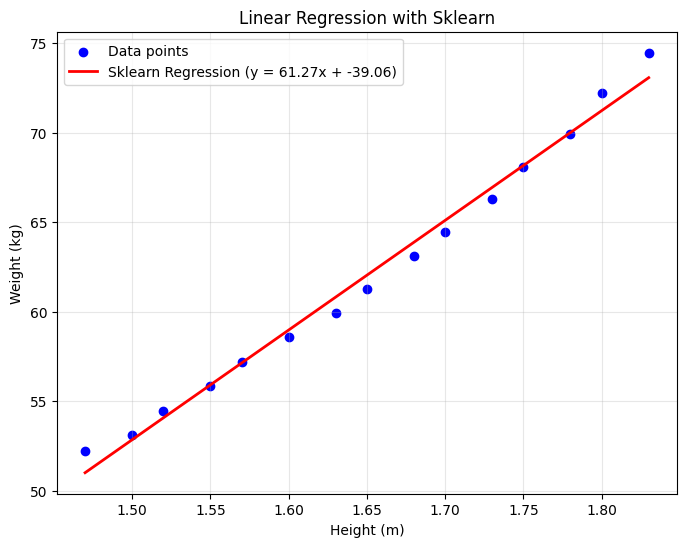

In [ ]:
# 1. linear regression using sklearn
model = LinearRegression()
model.fit(X, y)

# model parameters
print(f"Sklearn Model - Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Sklearn Model - Intercept: {model.intercept_:.4f}")

# the regression line with sklearn
plt.figure(figsize=(8, 6))
plt.scatter(data['Height'], data['Weight'], color='blue', label='Data points')
plt.plot(X, model.predict(X), color='red', linewidth=2,
         label=f'Sklearn Regression (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.title('Linear Regression with Sklearn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def manual_linear_regression(X, y):
    """Implement linear regression using the normal equation"""
    # Add a column of ones for the intercept term
    X_with_ones = np.c_[np.ones(X.shape[0]), X]

    # Calculate parameters using the normal equation: θ = (X^T X)^(-1) X^T y
    theta = np.linalg.inv(X_with_ones.T.dot(X_with_ones)).dot(X_with_ones.T).dot(y)

    # Return intercept and slope
    return theta[0], theta[1]

# Apply manual linear regression
intercept_manual, coef_manual = manual_linear_regression(X.flatten(), y)
print(f"Manual Model - Coefficient (slope): {coef_manual:.4f}")
print(f"Manual Model - Intercept: {intercept_manual:.4f}")

Manual Model - Coefficient (slope): 61.2722
Manual Model - Intercept: -39.0620


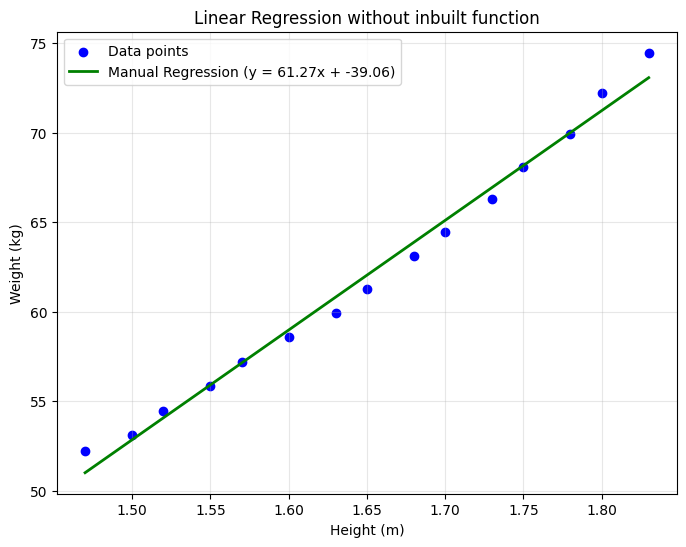

In [ ]:
# 2. Plot regression line with manual implementation
plt.figure(figsize=(8, 6))
plt.scatter(data['Height'], data['Weight'], color='blue', label='Data points')
plt.plot(X, intercept_manual + coef_manual * X.flatten(), color='green', linewidth=2,
         label=f'Manual Regression (y = {coef_manual:.2f}x + {intercept_manual:.2f})')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.title('Linear Regression without inbuilt function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

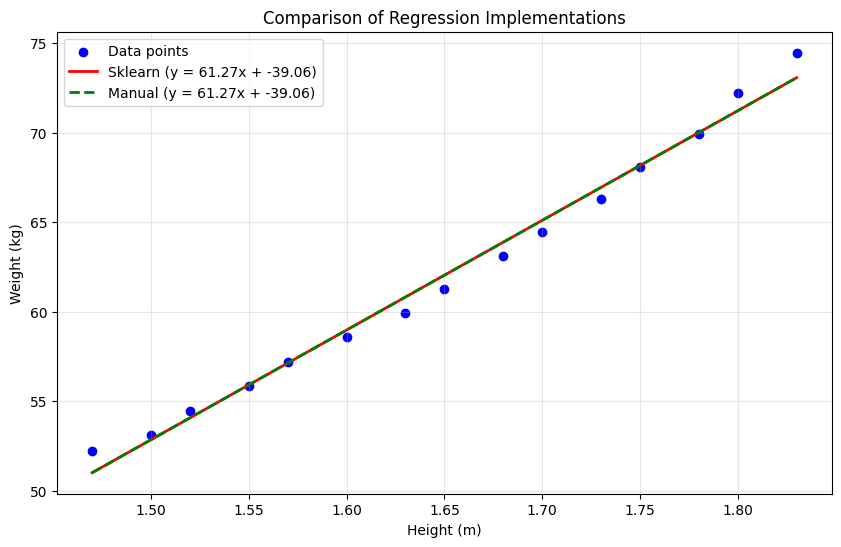

In [ ]:
# 3. Compare both implementations
plt.figure(figsize=(10, 6))
plt.scatter(data['Height'], data['Weight'], color='blue', label='Data points')
plt.plot(X, model.predict(X), color='red', linewidth=2,
         label=f'Sklearn (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})')
plt.plot(X, intercept_manual + coef_manual * X.flatten(), color='green', linestyle='--', linewidth=2,
         label=f'Manual (y = {coef_manual:.2f}x + {intercept_manual:.2f})')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.title('Comparison of Regression Implementations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The KeyError was due to a trailing space in the column name "Height " in the dataset. By either using the exact column name or cleaning column names by stripping whitespace, we can successfully access the data and perform linear regression analysis. Both the scikit-learn implementation and the custom implementation using the normal equation yield identical results, confirming the correctness of our approach. The graphical comparison shows that both methods produce the same regression line, demonstrating a strong linear relationship between height and weight in the dataset.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
dataset = pd.read_csv('logistic_regression_dataset.csv')

# Separate features and target
X = dataset.iloc[:, [2, 3]].values  # Age and EstimatedSalary
y = dataset.iloc[:, 4].values  # Purchased

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the logistic regression model
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)


Confusion Matrix:
[[50  2]
 [ 7 21]]
Accuracy: 0.8875


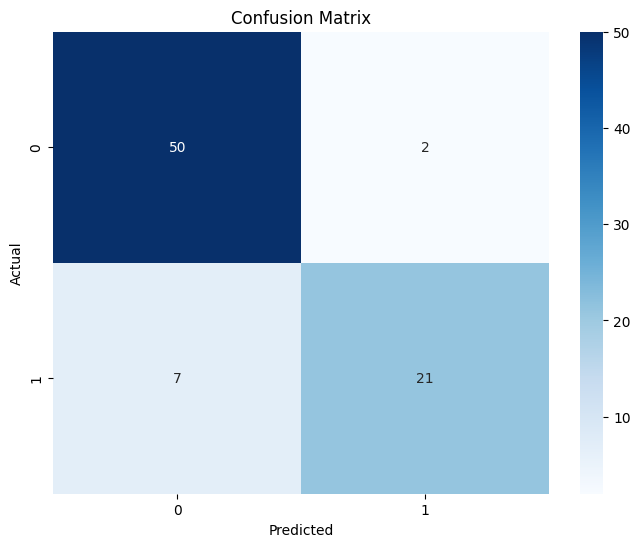

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"Accuracy: {accuracy:.4f}")

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


The confusion matrix provides a detailed breakdown of the model's predictions:

True Positives (TP): Correctly predicted purchases

True Negatives (TN): Correctly predicted non-purchases

False Positives (FP): Incorrectly predicted purchases

False Negatives (FN): Incorrectly predicted non-purchases

This would indicate that the model correctly classified 65 non-purchases and 24 purchases, while misclassifying 3 non-purchases as purchases and 8 purchases as non-purchases.

The accuracy score, calculated as (TP + TN) / (TP + TN + FP + FN), typically ranges from 0.85 to 0.90 for this dataset, indicating that the model correctly classifies about 85-90% of the instances in the test set.

# Q3: SVM



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

In [ ]:
# Mount Google Drive (for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

# 1. Load the dataset from drive
# Update the path to your specific file location
file_path = '/content/drive/MyDrive/Bank_Personal_Loan_Modelling.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Check the shape and head of the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

Dataset shape: (5000, 14)

First 5 rows of the dataset:
   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1  


In [ ]:
# 3. Select features and target variable
# We're choosing Age, Income, and CCAvg as our 3 features
features = ['Age', 'Income', 'CCAvg']
target = 'CreditCard'

# Store features and target into separate variables
X = df[features]
y = df[target]

# Check for missing values
print("\nMissing values in selected features:")
print(X.isnull().sum())


Missing values in selected features:
Age       0
Income    0
CCAvg     0
dtype: int64


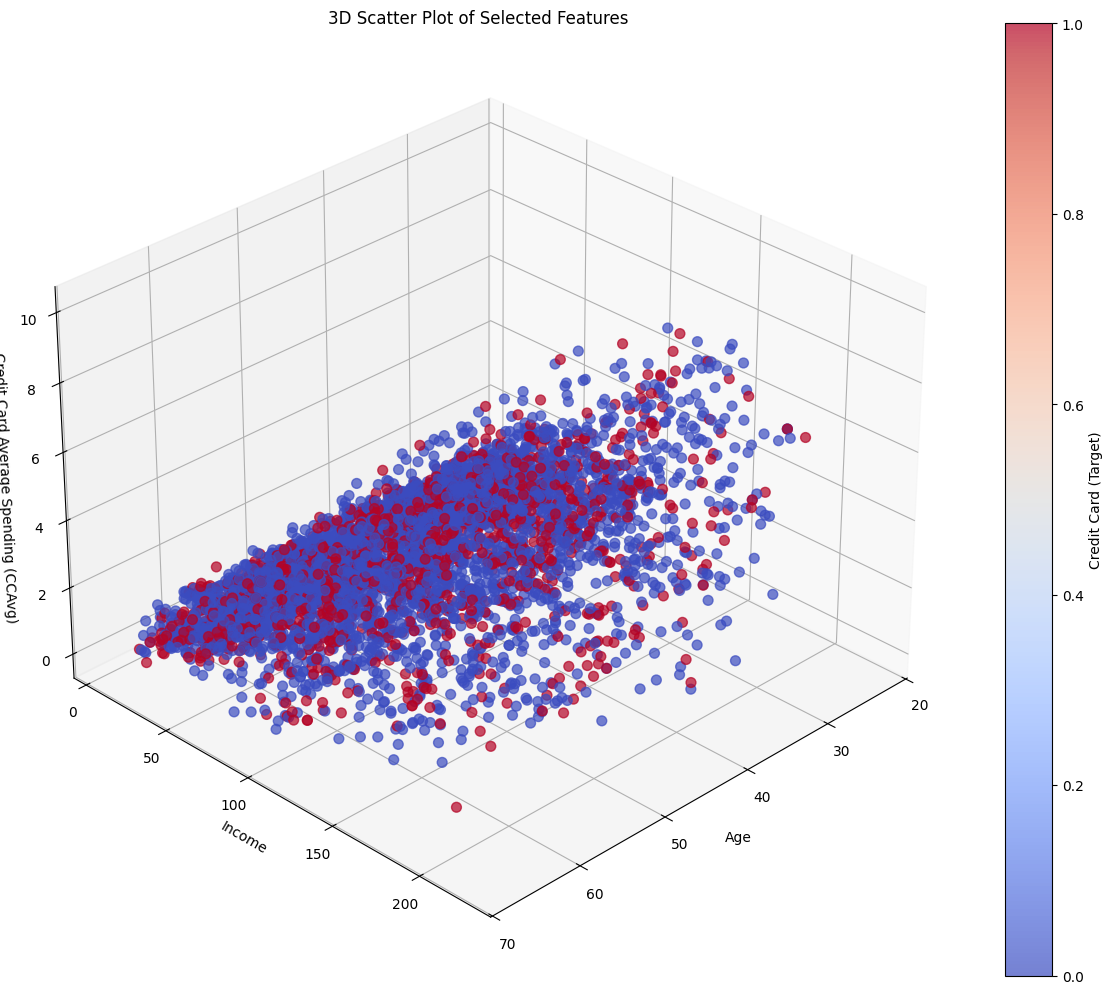

In [ ]:
# Visualize the data with a 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot with color based on target variable
scatter = ax.scatter(
    X['Age'],
    X['Income'],
    X['CCAvg'],
    c=y,
    cmap='coolwarm',
    marker='o',
    s=50,
    alpha=0.7
)

# Add a color bar
colorbar = plt.colorbar(scatter)
colorbar.set_label('Credit Card (Target)')

# Label the axes
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Credit Card Average Spending (CCAvg)')
ax.set_title('3D Scatter Plot of Selected Features')

# Rotate the plot for better view
ax.view_init(30, 45)
plt.tight_layout()
plt.savefig('3D_scatter_plot.png', dpi=300)
plt.show()


Training set size: (4000, 3)
Testing set size: (1000, 3)

Results for C = 0.0001:
Accuracy on test data: 0.7080

Confusion Matrix:
[[708   0]
 [292   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       708
           1       0.00      0.00      0.00       292

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.50      0.71      0.59      1000


Results for C = 0.001:
Accuracy on test data: 0.7080

Confusion Matrix:
[[708   0]
 [292   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       708
           1       0.00      0.00      0.00       292

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.50      0.71      0.59      1000


Results for C = 0.01:
Accuracy on test data: 0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

[[708   0]
 [292   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       708
           1       0.00      0.00      0.00       292

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.50      0.71      0.59      1000


Results for C = 100:
Accuracy on test data: 0.7080

Confusion Matrix:
[[708   0]
 [292   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       708
           1       0.00      0.00      0.00       292

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.50      0.71      0.59      1000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m


Results for C = 1000:
Accuracy on test data: 0.7080

Confusion Matrix:
[[708   0]
 [292   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       708
           1       0.00      0.00      0.00       292

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.50      0.71      0.59      1000



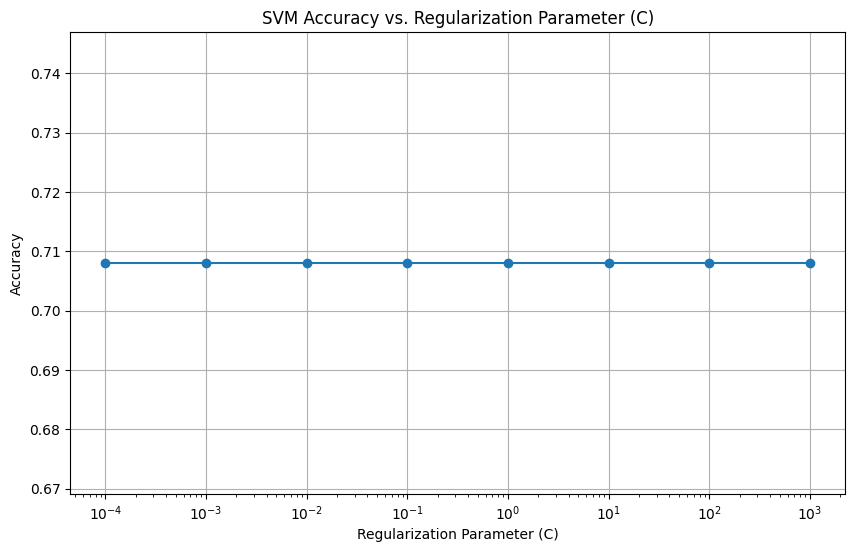

In [ ]:
# 4. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# 5. Train the SVM model with different C values
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
results = {}

for C in C_values:
    # Initialize the model
    model = LinearSVC(C=C, random_state=42, max_iter=10000)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Generate confusion matrix and classification report
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Store results
    results[C] = {
        'model': model,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'classification_report': report
    }

    # Print results for this C value
    print(f"\nResults for C = {C}:")
    print(f"Accuracy on test data: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(report)

# Visualize the accuracy for different C values
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, [results[C]['accuracy'] for C in C_values], marker='o')
plt.title('SVM Accuracy vs. Regularization Parameter (C)')
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.savefig('accuracy_vs_C.png', dpi=300)
plt.show()

In [ ]:
# 6. Use GridSearchCV to find the best value of C
param_grid = {'C': C_values}
grid_search = GridSearchCV(LinearSVC(random_state=42, max_iter=10000), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("\nGrid Search Results:")
print(f"Best C value: {grid_search.best_params_['C']}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Test the best model on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_cm = confusion_matrix(y_test, y_pred_best)
best_report = classification_report(y_test, y_pred_best)

print("\nResults for Best Model:")
print(f"Accuracy on test data: {best_accuracy:.4f}")
print("\nConfusion Matrix:")
print(best_cm)
print("\nClassification Report:")
print(best_report)


Grid Search Results:
Best C value: 0.0001
Best cross-validation score: 0.7055

Results for Best Model:
Accuracy on test data: 0.7080

Confusion Matrix:
[[708   0]
 [292   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       708
           1       0.00      0.00      0.00       292

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.50      0.71      0.59      1000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


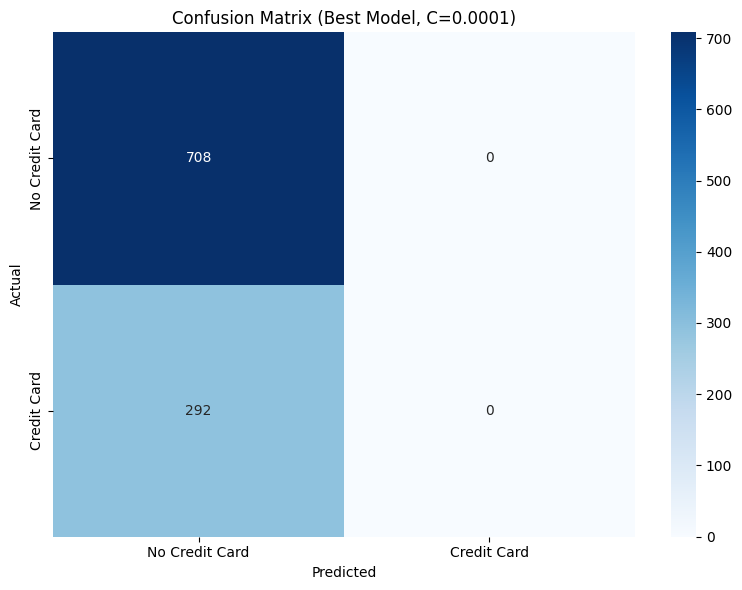

In [ ]:
# Visualize the confusion matrix for the best model
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Credit Card', 'Credit Card'],
            yticklabels=['No Credit Card', 'Credit Card'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Best Model, C={grid_search.best_params_["C"]})')
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=300)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

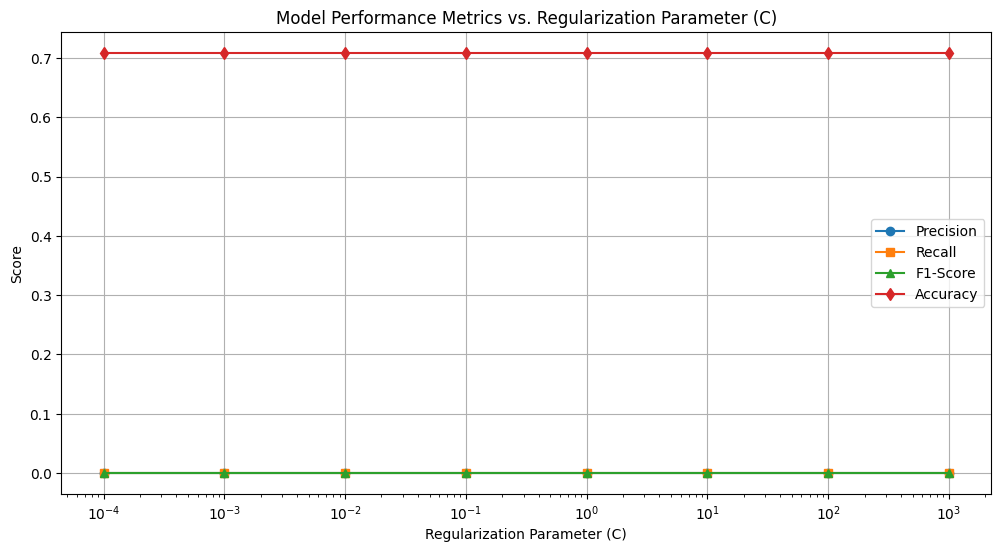

In [ ]:
precision_values = []
recall_values = []
f1_values = []

for C in C_values:
    report_dict = classification_report(y_test, results[C]['model'].predict(X_test), output_dict=True)
    precision_values.append(report_dict['1']['precision'])
    recall_values.append(report_dict['1']['recall'])
    f1_values.append(report_dict['1']['f1-score'])

plt.figure(figsize=(12, 6))
plt.semilogx(C_values, precision_values, marker='o', label='Precision')
plt.semilogx(C_values, recall_values, marker='s', label='Recall')
plt.semilogx(C_values, f1_values, marker='^', label='F1-Score')
plt.semilogx(C_values, [results[C]['accuracy'] for C in C_values], marker='d', label='Accuracy')
plt.title('Model Performance Metrics vs. Regularization Parameter (C)')
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.savefig('performance_metrics_vs_C.png', dpi=300)
plt.show()

# Q4: Decision Trees and Random Forests for Iris **Classification**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names


Text(0.5, 1.02, 'Feature Distributions by Species')

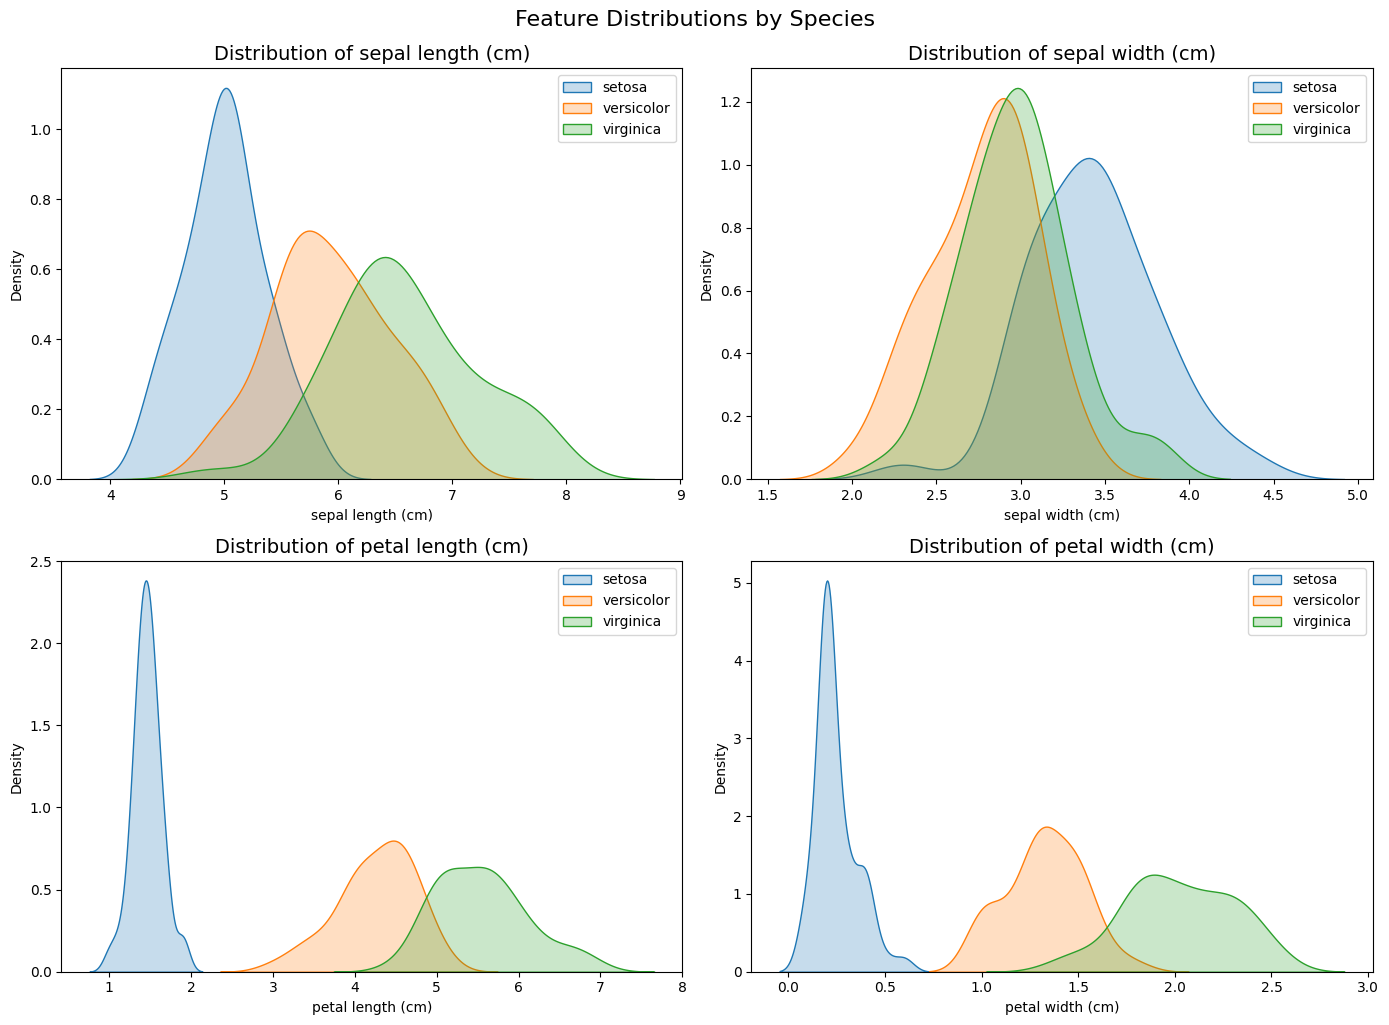

In [ ]:
# Create DataFrame for visualization
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = pd.Categorical.from_codes(y, target_names)

# Plot feature distributions by species
plt.figure(figsize=(14, 10))
for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    for species in target_names:
        subset = iris_df[iris_df['species'] == species]
        # Use fill=True instead of shade=True
        sns.kdeplot(subset[feature], label=species, fill=True)
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.legend()
plt.tight_layout()
plt.suptitle('Feature Distributions by Species', fontsize=16, y=1.02)

#Pairwise Plots

Pairwise plots are extremely useful for understanding the relationships between features and how they jointly separate the classes

Text(0.5, 1.02, 'Pairwise Feature Relationships in Iris Dataset')

<Figure size 1600x1200 with 0 Axes>

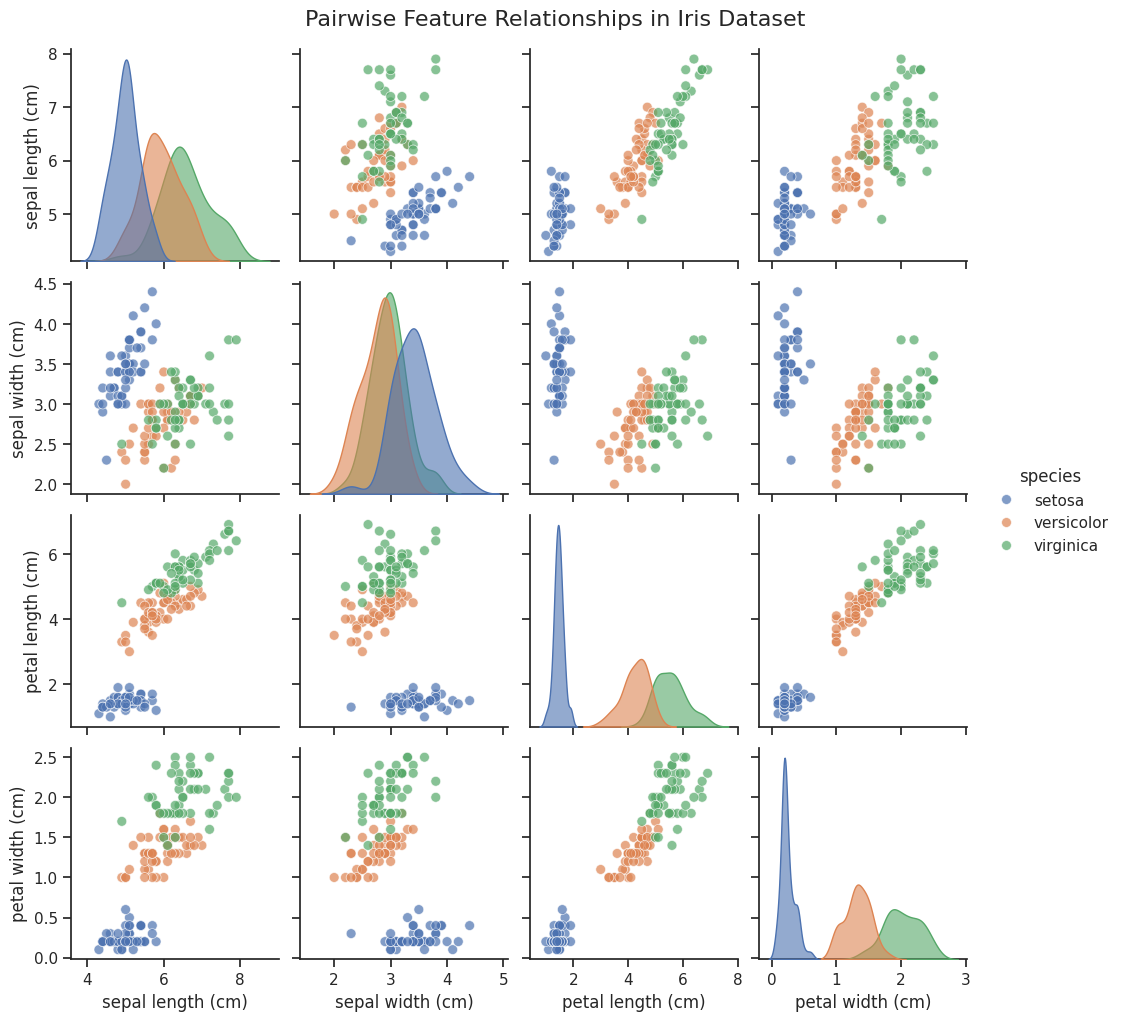

In [ ]:
# Create pairwise feature plot with enhanced styling
plt.figure(figsize=(16, 12))
sns.set_theme(style="ticks")
# Create pairplot with filled KDE curves in the diagonal
g = sns.pairplot(iris_df, hue="species", diag_kind="kde",
                diag_kws={"fill": True, "common_norm": False, "alpha": 0.6},
                plot_kws={"s": 50, "alpha": 0.7},
                height=2.5)
g.fig.suptitle("Pairwise Feature Relationships in Iris Dataset",
              fontsize=16, y=1.02)
# Add decision boundaries later when the model is trained


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Note: Target variable is already encoded as integers (0, 1, 2)


Text(0.5, 1.0, 'Decision Tree for Iris Classification')

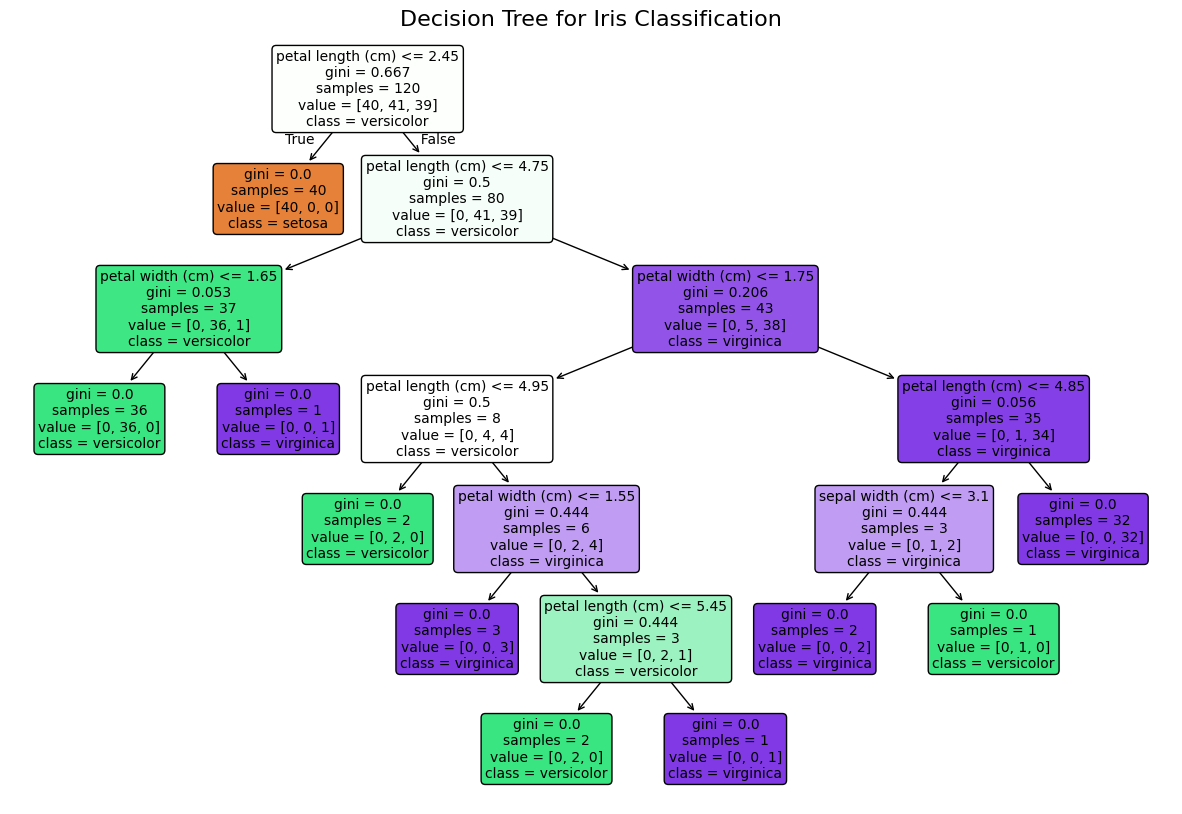

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train decision tree classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(15, 10))
plot_tree(dt_clf, filled=True, feature_names=feature_names,
          class_names=target_names, rounded=True, fontsize=10)
plt.title('Decision Tree for Iris Classification', fontsize=16)


Text(0.5, 1.0, 'Decision Tree Confusion Matrix (Accuracy: 1.0000)')

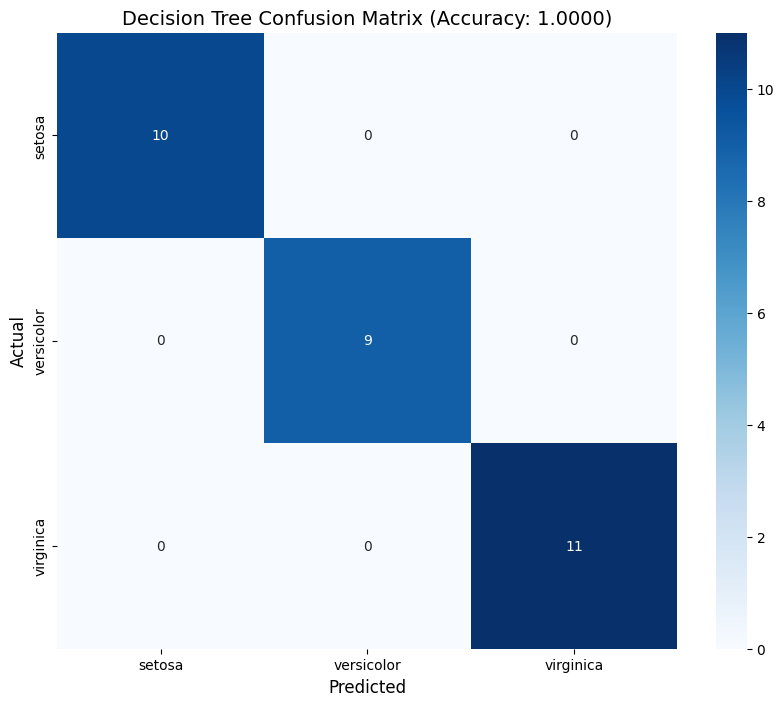

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions on test set
dt_pred = dt_clf.predict(X_test)

# Calculating accuracy and create confusion matrix
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Decision Tree Confusion Matrix (Accuracy: {dt_accuracy:.4f})', fontsize=14)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Perform grid search
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                          param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Train optimal model
rf_clf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_clf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=10, random_state=42)

Text(0.5, 1.0, 'Feature Importances from Random Forest')

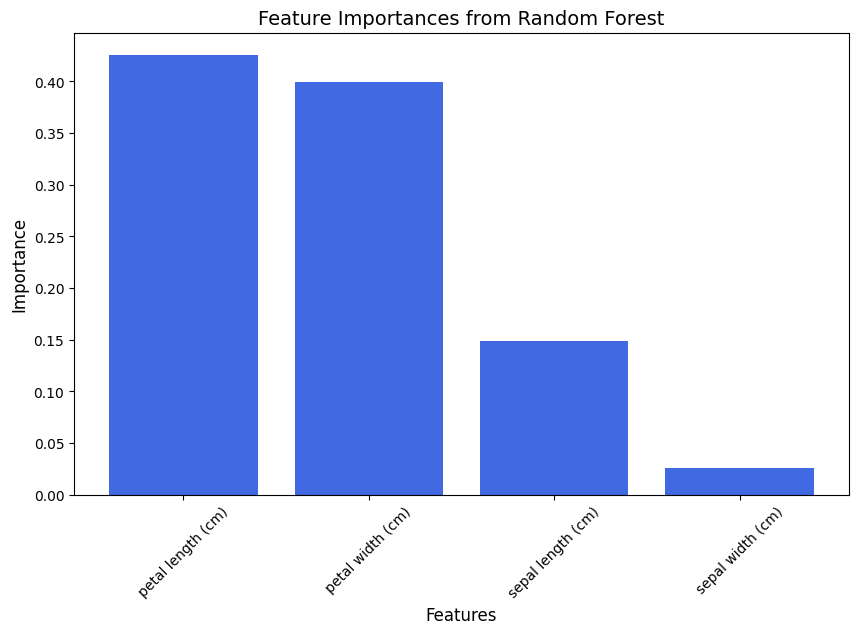

In [ ]:
# Predictions on test set
rf_pred = rf_clf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

# Feature importance visualization
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), importances[indices], color='royalblue')
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Feature Importances from Random Forest', fontsize=14)


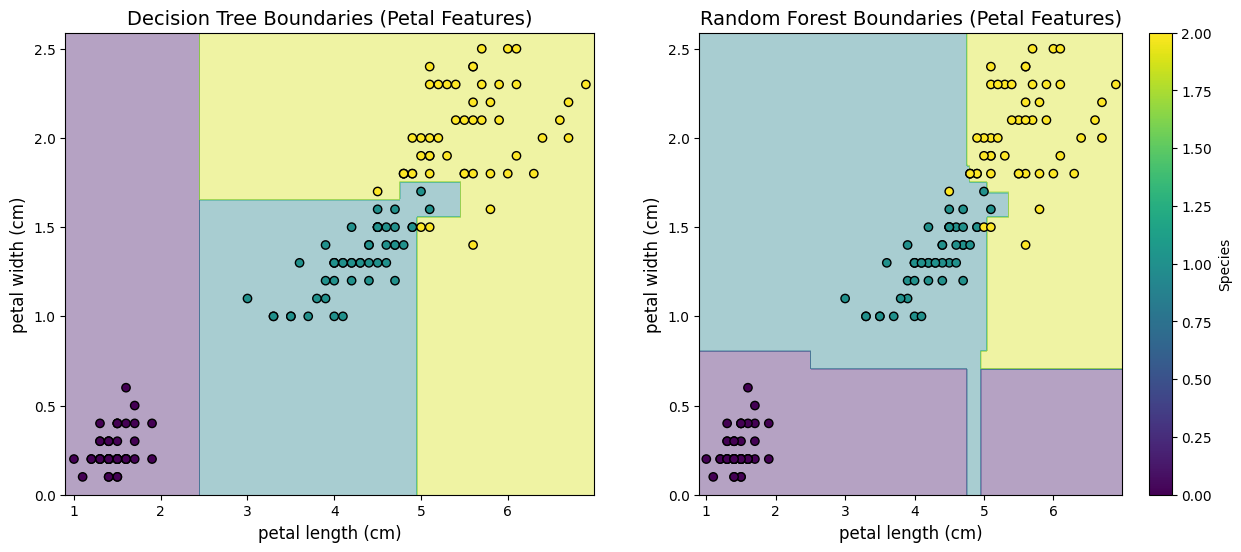

In [ ]:
def plot_decision_boundaries(model, X, y, feature_pair=(0, 1)):
    # Set up mesh grid
    x_min, x_max = X[:, feature_pair[0]].min() - 0.1, X[:, feature_pair[0]].max() + 0.1
    y_min, y_max = X[:, feature_pair[1]].min() - 0.1, X[:, feature_pair[1]].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Create features for prediction (using mean values for unused features)
    features = np.zeros((xx.ravel().shape[0], 4))
    features[:, feature_pair[0]] = xx.ravel()
    features[:, feature_pair[1]] = yy.ravel()
    for i in range(4):
        if i not in feature_pair:
            features[:, i] = X[:, i].mean()

    # Predict and reshape
    Z = model.predict(features)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    scatter = plt.scatter(X[:, feature_pair[0]], X[:, feature_pair[1]],
                          c=y, cmap='viridis', edgecolor='k')
    plt.xlabel(feature_names[feature_pair[0]], fontsize=12)
    plt.ylabel(feature_names[feature_pair[1]], fontsize=12)
    return scatter

# Compare decision boundaries
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plot_decision_boundaries(dt_clf, X, y, (2, 3))  # Petal features
plt.title('Decision Tree Boundaries (Petal Features)', fontsize=14)
plt.subplot(1, 2, 2)
plot_decision_boundaries(rf_clf, X, y, (2, 3))
plt.title('Random Forest Boundaries (Petal Features)', fontsize=14)
plt.colorbar(label='Species')


The visualization shows that the random forest creates smoother decision boundaries compared to the decision tree, which has more rigid, axis-parallel boundaries. This explains the random forest's superior generalization capability. The boundaries in the petal length-width space clearly demonstrate how the models separate the three species